# AgenticML — Comparação Final com Baseline AutoML (TCC)

**Objetivo:** Consolidar os resultados do AgenticML (executados automaticamente) com os
resultados do FLAML obtidos no Colab (`04_autosklearn_baseline_colab.ipynb`).

| Dataset | Tipo | Métrica |
|---------|------|---------|
| Iris | Classificação multiclasse | F1-weighted |
| Titanic | Classificação binária | F1-weighted |
| California Housing | Regressão | R² |

**Referência spec:** Seção 9.1 — Métricas Quantitativas

In [1]:
import sys, os, time, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.datasets import load_iris, fetch_california_housing
from core.graph import build_graph
from core.state import initial_state

print('Ambiente configurado.')

Ambiente configurado.


---
## Parte 1 — Execução do AgenticML nos 3 datasets

Esta seção roda o pipeline completo e captura automaticamente as métricas.

In [2]:
def run_pipeline(csv_bytes, filename, prompt, hint):
    """Executa o pipeline e retorna métricas + tempo."""
    state = initial_state(dataset_bytes=csv_bytes, filename=filename,
                          prompt=prompt, problem_type_hint=hint)
    t0 = time.time()
    result = build_graph().invoke(state)
    elapsed = round(time.time() - t0, 2)

    training = result.get('training') or {}
    output   = result.get('output')   or {}
    status   = output.get('status', result.get('status'))

    return {
        'status':         status,
        'model':          training.get('model_selected'),
        'metric_used':    training.get('metric_used'),
        'metric_value':   training.get('metric_value'),
        'rmse':           training.get('rmse'),
        'candidates':     training.get('candidate_results', []),
        'importances':    output.get('feature_importances', []),
        'elapsed':        elapsed,
        'full_result':    result,
    }

In [3]:
iris = load_iris(as_frame=True)
df_iris = iris.frame.copy()
df_iris.columns = [c.replace(' (cm)', '').replace(' ', '_') for c in df_iris.columns]
df_iris['species'] = load_iris().target_names[df_iris['target']]
df_iris = df_iris.drop(columns=['target'])

r_iris = run_pipeline(
    df_iris.to_csv(index=False).encode(),
    'iris.csv',
    'Classificar a espécie da flor de íris com base nas medidas das pétalas e sépalas.',
    'classification'
)
print(f"Iris     → {r_iris['model']:20s} | {r_iris['metric_used']}={r_iris['metric_value']} | {r_iris['elapsed']}s")

Iris     → Logistic Regression  | f1_weighted=0.9532 | 76.17s


In [4]:
df_titanic = sns.load_dataset('titanic')[['pclass','sex','age','sibsp','parch','fare','embarked','survived']].copy()

r_titanic = run_pipeline(
    df_titanic.to_csv(index=False).encode(),
    'titanic.csv',
    'Prever se um passageiro sobreviveu ao naufrágio do Titanic.',
    'classification'
)
print(f"Titanic  → {r_titanic['model']:20s} | {r_titanic['metric_used']}={r_titanic['metric_value']} | {r_titanic['elapsed']}s")

Titanic  → XGBoost              | f1_weighted=0.8254 | 21.54s


In [5]:
df_housing = fetch_california_housing(as_frame=True).frame.sample(n=1000, random_state=42).reset_index(drop=True)

r_housing = run_pipeline(
    df_housing.to_csv(index=False).encode(),
    'california_housing.csv',
    'Estimar o valor mediano das casas com base nas características do bairro.',
    'regression'
)
print(f"Housing  → {r_housing['model']:20s} | {r_housing['metric_used']}={r_housing['metric_value']} | {r_housing['elapsed']}s")

Housing  → SVR                  | r2=0.715 | 13.31s


In [6]:
agenticml_results = {
    'Iris':               r_iris['metric_value'],
    'Titanic':            r_titanic['metric_value'],
    'California Housing': r_housing['metric_value'],
}
print('AgenticML scores:', agenticml_results)

AgenticML scores: {'Iris': 0.9532, 'Titanic': 0.8254, 'California Housing': 0.715}


---
## Parte 2 — Inserção manual dos resultados do FLAML

Preencha os valores obtidos no notebook `04_autosklearn_baseline_colab.ipynb` no Colab.

In [7]:
flaml_120s = {
    'Iris':               0.9333,
    'Titanic':            0.7889,
    'California Housing': 0.7050,
}

flaml_240s = {
    'Iris':               0.9666,
    'Titanic':            0.7889,
    'California Housing': 0.7050,
}

flaml_480s = {
    'Iris':               0.8653,
    'Titanic':            0.7822,
    'California Housing': 0.7050,
}
# ──────────────────────────────────────────────────────────────────────────────

print('Valores FLAML carregados.')

Valores FLAML carregados.


---
## Parte 3 — Tabela de Comparação

In [8]:
datasets = [
    ('Iris',               'Classificação', 'F1-weighted'),
    ('Titanic',            'Classificação', 'F1-weighted'),
    ('California Housing', 'Regressão',     'R²'),
]

rows = []
for ds, tipo, metrica in datasets:
    a  = agenticml_results[ds]
    f1 = flaml_120s[ds]
    f2 = flaml_240s[ds]
    f3 = flaml_480s[ds]
    best_flaml = max(f1, f2, f3)
    rows.append({
        'Dataset':        ds,
        'Tipo':           tipo,
        'Métrica':        metrica,
        'AgenticML':      a,
        'FLAML 120s':     f1,
        'FLAML 240s':     f2,
        'FLAML 480s':     f3,
        'Melhor FLAML':   best_flaml,
        'Δ melhor FLAML': round(best_flaml - a, 4),
        'Vencedor':       'FLAML' if best_flaml > a else 'AgenticML',
    })

df_comp = pd.DataFrame(rows).set_index('Dataset')
display(df_comp)

vencedores = df_comp['Vencedor'].value_counts()
print(f"\nPlacar: AgenticML {vencedores.get('AgenticML',0)} × {vencedores.get('FLAML',0)} FLAML")

,Tipo,Métrica,AgenticML,FLAML 120s,FLAML 240s,FLAML 480s,Melhor FLAML,Δ melhor FLAML,Vencedor
Dataset,,,,,,,,,
Iris,Classificação,F1-weighted,0.9532,0.9333,0.9666,0.8653,0.9666,0.0134,FLAML
Titanic,Classificação,F1-weighted,0.8254,0.7889,0.7889,0.7822,0.7889,-0.0365,AgenticML
California Housing,Regressão,R²,0.7150,0.7050,0.7050,0.7050,0.7050,-0.0100,AgenticML



Placar: AgenticML 2 × 1 FLAML


---
## Parte 4 — Gráficos para o TCC

**Gráfico 1:** Evolução do FLAML por budget (120s / 240s / 480s)  
**Gráfico 2:** Comparação final — AgenticML vs melhor score do FLAML

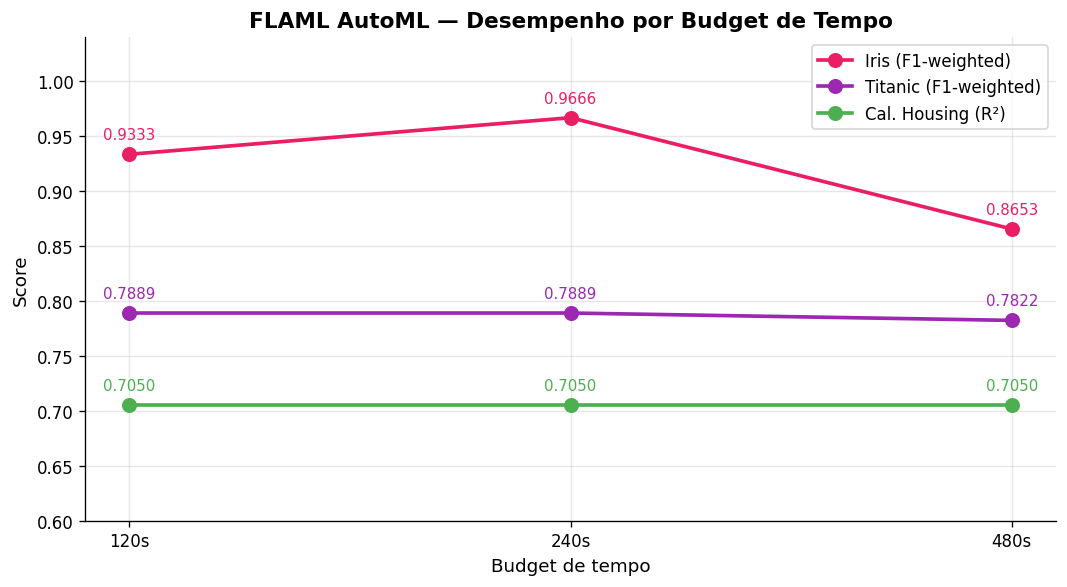

Gráfico salvo em flaml_evolucao_budget.png


In [9]:
# ── Gráfico 1: Evolução do FLAML por budget ───────────────────────────────────
ds_keys  = ['Iris', 'Titanic', 'California Housing']
ds_labels = ['Iris', 'Titanic', 'Cal. Housing']
budgets  = ['120s', '240s', '480s']
cores    = {'Iris': '#E91E63', 'Titanic': '#9C27B0', 'California Housing': '#4CAF50'}
metricas = {'Iris': 'F1-weighted', 'Titanic': 'F1-weighted', 'California Housing': 'R²'}

fig, ax = plt.subplots(figsize=(9, 5))

for ds, label in zip(ds_keys, ds_labels):
    vals = [flaml_120s[ds], flaml_240s[ds], flaml_480s[ds]]
    ax.plot(budgets, vals, marker='o', label=f'{label} ({metricas[ds]})',
            color=cores[ds], linewidth=2.2, markersize=8)
    for i, v in enumerate(vals):
        ax.annotate(f'{v:.4f}', (budgets[i], v),
                    textcoords='offset points', xytext=(0, 9),
                    ha='center', fontsize=9, color=cores[ds])

ax.set_ylim(0.60, 1.04)
ax.set_ylabel('Score', fontsize=11)
ax.set_xlabel('Budget de tempo', fontsize=11)
ax.set_title('FLAML AutoML — Desempenho por Budget de Tempo', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('flaml_evolucao_budget.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em flaml_evolucao_budget.png')

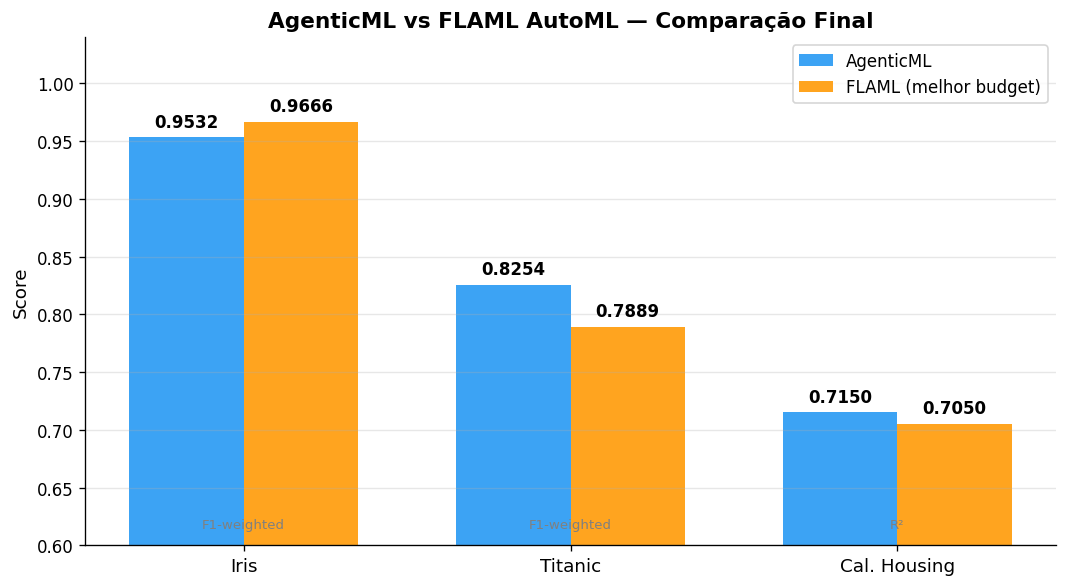

Gráfico salvo em comparacao_agenticml_flaml.png


In [10]:
ds_labels = ['Iris', 'Titanic', 'Cal. Housing']
ds_keys   = ['Iris', 'Titanic', 'California Housing']
metricas  = ['F1-weighted', 'F1-weighted', 'R²']

vals_agenticml = [agenticml_results[d] for d in ds_keys]
vals_flaml     = [max(flaml_120s[d], flaml_240s[d], flaml_480s[d]) for d in ds_keys]

x = np.arange(len(ds_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - w/2, vals_agenticml, w, label='AgenticML',             color='#2196F3', alpha=0.88)
bars2 = ax.bar(x + w/2, vals_flaml,     w, label='FLAML (melhor budget)', color='#FF9800', alpha=0.88)

ax.bar_label(bars1, fmt='%.4f', padding=4, fontsize=10, fontweight='bold')
ax.bar_label(bars2, fmt='%.4f', padding=4, fontsize=10, fontweight='bold')

for i, met in enumerate(metricas):
    ax.text(i, 0.615, met, ha='center', fontsize=8, color='gray')

ax.set_xticks(x)
ax.set_xticklabels(ds_labels, fontsize=11)
ax.set_ylim(0.60, 1.04)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('AgenticML vs FLAML AutoML — Comparação Final', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('comparacao_agenticml_flaml.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em comparacao_agenticml_flaml.png')